--- Generating Chart: Observed vs SARIMA (ANNUAL MEAN) ---


Success! Annual chart saved at: ..\figuras\figure-hindcasting-validation-annual-sarima-only.pdf


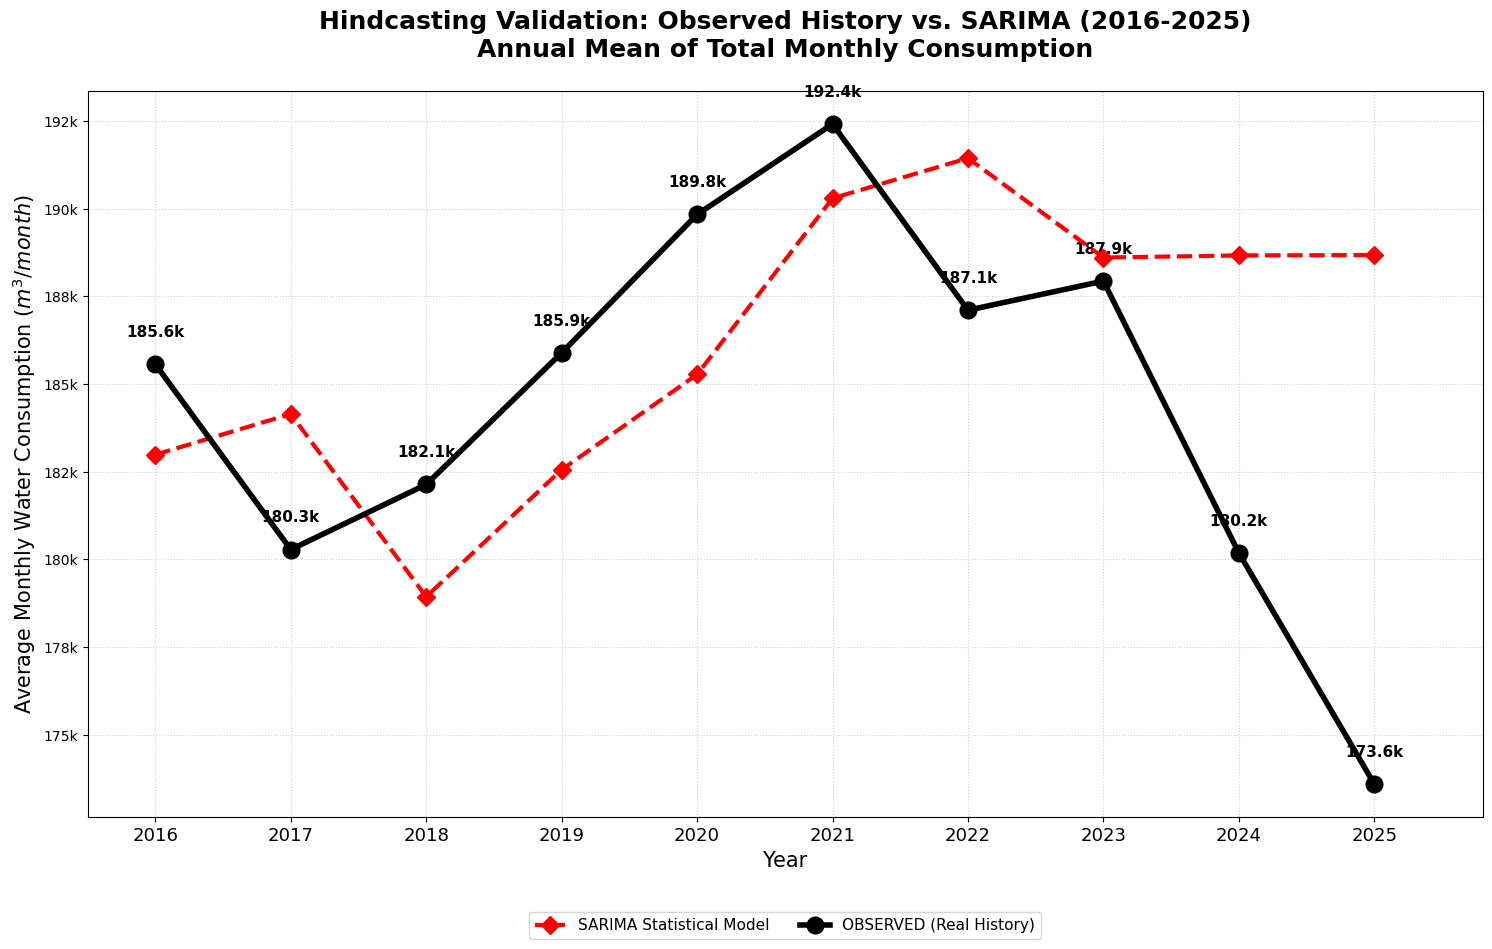

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import os

# ==========================================
# 1. Configurations and Paths
# ==========================================
BASE_PATH = '..' 

# Input Filenames
REAL_FILE = 'Tabela_consumo_real_historico_2016_2025.csv'
SARIMA_FILE = 'previsao_consumo_sarima_2016_2025.csv' 

# Output Configuration
OUTPUT_DIR = os.path.join(BASE_PATH, 'figuras')
OUTPUT_FIG = 'figure-hindcasting-validation-annual-sarima-only.pdf'

# Search Directories
INPUT_DIR_INCLUDES = os.path.join(BASE_PATH, 'includes')
INPUT_DIR_IA = os.path.join(BASE_PATH, 'modelos IA')

def aggregate_annually_mean(df, date_col, value_cols):
    """ Aggregates monthly data points into annual means. """
    df_yearly = df.copy()
    df_yearly['Year'] = df_yearly[date_col].dt.year
    return df_yearly.groupby('Year')[value_cols].mean().reset_index()

def main():
    print("--- Generating Chart: Observed vs SARIMA (ANNUAL MEAN) ---")

    # ==========================================
    # 2. Data Loading and Preparation
    # ==========================================
    
    # A. Load Real Historical Data
    path_real = os.path.join(INPUT_DIR_INCLUDES, REAL_FILE)
    df_real = pd.read_csv(path_real, sep=';', decimal='.')
    df_real['Date'] = pd.to_datetime(df_real['AM_REFERENCIA'].astype(str) + '01', format='%Y%m%d')
    df_real.rename(columns={'real_total_consumption': 'Real'}, inplace=True)

    # B. Load SARIMA Prediction Results
    path_sarima = os.path.join(INPUT_DIR_IA, SARIMA_FILE)
    if os.path.exists(path_sarima):
        df_sarima = pd.read_csv(path_sarima)
        df_sarima['Date'] = pd.to_datetime(df_sarima['Date'])
    else:
        print(f"Warning: File {SARIMA_FILE} not found.")
        df_sarima = None

    # Annual Aggregation
    df_real_mean = aggregate_annually_mean(df_real, 'Date', ['Real'])
    
    if df_sarima is not None:
        df_sarima_mean = aggregate_annually_mean(df_sarima, 'Date', ['Projected_Consumption'])

    # ==========================================
    # 3. Plotting
    # ==========================================
    fig, ax = plt.subplots(figsize=(18, 11))

    # --- A. Plotting SARIMA Prediction ---
    if df_sarima is not None:
        ax.plot(df_sarima_mean['Year'], df_sarima_mean['Projected_Consumption'], label='SARIMA Statistical Model', 
                color='red', linestyle='--', linewidth=3, marker='D', markersize=9, zorder=26)

    # --- B. Plotting Historical Ground Truth (Highlighted) ---
    ax.plot(df_real_mean['Year'], df_real_mean['Real'], label='OBSERVED (Real History)', color='black',
            linestyle='-', linewidth=4, marker='o', markersize=12, zorder=30)

    # Annotations
    for x, y in zip(df_real_mean['Year'], df_real_mean['Real']):
        ax.annotate(f"{y/1000:.1f}k", (x, y), xytext=(0, 20), textcoords="offset points",
                    ha='center', fontsize=11, fontweight='bold', color='black')

    # ==========================================
    # 4. Final Formatting
    # ==========================================
    ax.set_ylabel('Average Monthly Water Consumption ($m^3/month$)', fontsize=15)
    ax.set_xlabel('Year', fontsize=15)
    
    years = df_real_mean['Year'].tolist()
    ax.set_xticks(years)
    ax.set_xticklabels(years, fontsize=13)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x/1000:.0f}k'))
    
    ax.set_xlim(years[0]-0.5, years[-1]+0.8)
    plt.grid(True, linestyle=':', alpha=0.6)

    plt.title('Hindcasting Validation: Observed History vs. SARIMA (2016-2025)\n'
              'Annual Mean of Total Monthly Consumption', 
              fontsize=18, fontweight='bold', pad=25)

    # Legend adjustment
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=2, 
               fontsize=11, frameon=True)
    
    plt.subplots_adjust(bottom=0.22)

    os.makedirs(OUTPUT_DIR, exist_ok=True)
    save_path = os.path.join(OUTPUT_DIR, OUTPUT_FIG)
    plt.savefig(save_path, format='pdf', bbox_inches='tight')
    
    print(f"Success! Annual chart saved at: {save_path}")
    plt.show()

if __name__ == "__main__":
    main()